# Two-Spool Turbofan — Fuel-Flow Control + Environment + Plots

This notebook builds a simple two-spool turbofan (Fan → LPC → HPC → Comb → HPT → LPT) with separate core & bypass nozzles using **Huracán**.

What’s new:
- **Fuel-flow control** mode (sets fuel mass flow directly per waypoint)
- **Tt4 control** mode (kept for convenience)
- **Environment control**: ISA ΔT offset (°C), custom altitude/Mach profiles
- **Plots**: thrust vs altitude, TSFC vs Mach, time-series (thrust, fuel, T0/P0 stations)

Use `fly_profile(...)` to run a flight profile in either control mode.

In [1]:
# Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from huracan.engine import system
from huracan.components.channels import inlet, nozzle
from huracan.components.rotary import fan, compressor, turbine
from huracan.components.power.combustion import combustion_chamber
from huracan.thermo.fluids import gas, fuel 

## Atmosphere (ISA + ΔT)
Simple ISA up to 11 km with a temperature offset (ΔT_isa_C).

In [2]:
R = 287.05   # J/(kg·K)
g0 = 9.80665
T0_isa = 288.15
p0_isa = 101325.0
L = -0.0065

def isa_tp(h_m: float):
    h = float(h_m)
    if h <= 11000.0:
        T = T0_isa + L*h
        p = p0_isa * (T/T0_isa) ** (-g0/(L*R))
    else:
        T11 = T0_isa + L*11000.0
        p11 = p0_isa * (T11/T0_isa) ** (-g0/(L*R))
        p = p11 * math.exp(-g0*(h-11000.0)/(R*T11))
        T = T11
    return T, p

def isa_tp_offset(h_m: float, dT_C: float = 0.0):
    T, p = isa_tp(h_m)
    return T + dT_C, p

## Helpers: streams, TSFC, safe exit velocity
We’ll avoid Huracán’s turbine `.t0` dependency by using an exit-velocity surrogate based on total vs static temperature.
*(It’s a simplification but robust for our demo.)*

In [3]:
def stream_totals(s):
    return float(s.gas.t_0), float(s.gas.p_0)

def tsfc_lbm_hr_lbf(thrust_N, fuel_kgps):
    return (fuel_kgps*2.20462*3600.0) / max(1e-9, thrust_N*0.224809)

def safe_v_exit_from_temperatures(Tt, Tstatic, cp):
    dT = max(0.0, Tt - Tstatic)
    return math.sqrt(max(0.0, 2.0 * cp * dT))


## Engine factory (two-spool)
We attach a **fuel object** to the combustor so Huracán can compute fuel mass flow. We support two control modes:
- **Tt4 control**: set `Comb.t01 = T_t4`
- **Fuel-flow control**: override the combustor’s internal `fmf` method to use a fixed `mf_fuel`

In [4]:
def make_engine_two_spool(
    bpr=9.6,
    pi_fan=1.54, eta_fan=0.92,
    pi_lpc=1.54, eta_lpc=0.89,
    pi_hpc=9.86,    eta_hpc=0.89,
    pi_comb = 0.98,  eta_comb = 0.965,
    eta_inlet=0.998,
    eta_hpt=0.89,
    eta_lpt=0.89,
    eta_noz=1,
    mf= 0,
    M  = 0.0, 
    t  = 281.65,
    p  = 89874
):
    g = gas(mf=mf*1000, # converting to grams_per_sec
        cp=lambda T: 1150 if T > 600 else 1000,
        k=lambda T: 1.33 if T > 600 else 1.4,
        m=M, t_0=t, p_0=p)
    f=fuel(LHV=43e6 )            # kerosene-like
    In     = inlet(eta=eta_inlet)
    Fan    = fan(eta=eta_fan, PI=pi_fan)
    LPC    = compressor(eta=eta_lpc, PI=pi_lpc)
    HPC    = compressor(eta=eta_hpc, PI=pi_hpc)
    Comb   = combustion_chamber(fuel=f,eta=eta_comb, PI=pi_comb )
    HPT    = turbine(eta=eta_hpt)
    LPT    = turbine(eta=eta_lpt)
    Nz = nozzle(eta=eta_noz)

    # Streams & topology
    s_fan = g - In - Fan
    s1core, s1bypass = s_fan*(bpr/(bpr+1))
    s_HPT =s1core-LPC- HPC -Comb-HPT-LPT
    s_pre_Nz = s_HPT- s1bypass
    s_Nz = s_pre_Nz - Nz


    # Shafts
    from huracan.engine import shaft
    shaft1 = shaft(Fan, LPC, LPT, eta=0.98, eta_gearbox=0.975)
    shaft2 = shaft(HPC, HPT, eta=0.98)

    eng = system(s_Nz)
    return eng, dict(Fan=s_fan, s_Bypass =s1bypass ,  
                      s_HPT=s_HPT ,s_pre_Nz=s_pre_Nz,s_NZ=s_Nz,fuel=mf)

## Runner: fly a profile (Tt4-control **or** Fuel-flow-control)
Each waypoint can specify either `T_t4` **or** `mf_fuel`.

**Waypoint schema**:
```python
{
  'h_m': <altitude m>,
  'M': <Mach>,
  'mf_fuel': 1500,      # g/s (fuel mass flow control)
}
```

You can also pass `dT_isa_C` to warm/cool the atmosphere globally.

In [5]:
def thrust_from_stream(s, T_amb):
    g = s.gas
    cp = g.cp(g.t_0)
    dT = max(1e-6, g.t_0 - T_amb)
    V_exit = np.sqrt(2 * cp * dT)
    return (g.mf/1000 )* (V_exit - g.v_0), V_exit

def fly_profile(waypoints,
                mdot_air=520.0,
                dT_isa_C=0.0):
    perf_rows, stn_rows = [], []
    for i, wp in enumerate(waypoints):
        h, M, _mf  = float(wp['h_m']), float(wp['M']), float(wp['mf_fuel'])
        T_amb, p_amb = isa_tp_offset(h, dT_isa_C)
        print("T_amb",T_amb)
        print("p_amb",p_amb)        
        eng, parts = make_engine_two_spool(mf=_mf*1000, t  = T_amb, p  = p_amb, M = M ) #dafults used
        s_fan, s_core, s_byp = parts['Fan'], parts['s_pre_Nz'], parts['s_Bypass']

        ## Ingest freestream
        # g = gas(mf=mdot_air,
        #       cp=lambda T: 1150 if T > 600 else 1000,
        #       k=lambda T: 1.33 if T > 600 else 1.4,
        #        m=M, t_0=T_amb, p_0=p_amb)


        # Solve once
        eng.run(log=True)

       # Thrusts
        thrust_core, V_exit_core = thrust_from_stream(s_core, T_amb)
        #print("thrust core:",thrust_core)
        thrust_byp,  V_exit_byp  = thrust_from_stream(s_byp,  T_amb)
        #print("thrust bypass:",thrust_byp)
        thrust = thrust_core + thrust_byp 
        #print("thrust:",thrust)

        #fuel = float(parts['Comb'].fuel.mf) if getattr(parts['Comb'].fuel, 'mf', None) is not None else 0.0
        print("Fuel:",parts['fuel'])
        fuel =  parts['fuel']#kg/hour
        print("fuel:",fuel)
        print("thrust:",thrust)
        sfc  = fuel/1000 / max(1e-9, thrust)
        tsfc = tsfc_lbm_hr_lbf(thrust_N =thrust, fuel_kgps= fuel/1000)     

        # Stations (totals from streams)
        T0_fan, P0_fan = stream_totals(s_fan)
        # After LPC and HPC we need intermediate runs; run was full so s_core now holds pre-nozzle totals
        T0_pre_noz, P0_pre_noz = stream_totals(s_core)

        perf_rows.append({
            'wp': i, 'h_m': h, 'M': M, 'thrust_N': thrust, 'fuel_kgps': fuel/1000,
            'sfc_kg_per_Ns': sfc, 'tsfc_lbm_hr_lbf': tsfc,
            'control': 'mf' if _mf is not None else 'Tt4',
            'control_value': _mf if _mf is not None else _Tt4
        })

        stn_rows.append({
            'wp': i, 'h_m': h, 'M': M,
            'T0_fan': T0_fan, 'P0_fan': P0_fan,
            'T0_pre_noz': T0_pre_noz, 'P0_pre_noz': P0_pre_noz,
            'T_ambient_K': T_amb
        })

    return pd.DataFrame(perf_rows), pd.DataFrame(stn_rows)

## Example profiles
- **Fuel-flow-controlled** block (pilot throttle style)

In [6]:


profile_mf = [
    {'h_m': 0,     'M': 0.0, 'mf_fuel': 1.2},
    {'h_m': 100,   'M': 0.2, 'mf_fuel': 1.2},
    {'h_m': 1000,  'M': 0.2, 'mf_fuel': 1.1},
    {'h_m': 2000,  'M': 0.3, 'mf_fuel': 1.1},
    {'h_m': 3000,  'M': 0.3, 'mf_fuel': 1.1},
    {'h_m': 7000,  'M': 0.3, 'mf_fuel': 1.1},
    {'h_m': 9000,  'M': 0.4, 'mf_fuel': 0.95},
    {'h_m': 11000, 'M': 0.5, 'mf_fuel': 0.90},
]

In [7]:
# Run both examples with a mild warm day (+10°C ISA)
perf_mf, stn_mf = fly_profile(profile_mf, dT_isa_C=10.0)
perf_mf

T_amb 298.15
p_amb 101325.0
2.nz     Nozzle
          T0 298.15 [K]
          p0 101325.0 [Pa]
Fuel: 1200.0
fuel: 1200.0
thrust: 160.99689437998487
T_amb 297.5
p_amb 100129.42585606562
2.nz     Nozzle
          T0 299.88 [K]
          p0 102961.198 [Pa]
Fuel: 1200.0
fuel: 1200.0
thrust: 82658.89818416197
T_amb 291.65
p_amb 89874.45515908135
2.nz     Nozzle
          T0 293.983199 [K]
          p0 92416.2055 [Pa]
Fuel: 1100.0
fuel: 1100.0
thrust: 75022.47202167557
T_amb 285.15
p_amb 79495.00908350243
2.nz     Nozzle
          T0 290.2827 [K]
          p0 84616.8952 [Pa]
Fuel: 1100.0
fuel: 1100.0
thrust: 111248.8534716315
T_amb 278.65
p_amb 70108.26833969312
2.nz     Nozzle
          T0 283.665699 [K]
          p0 74625.3641 [Pa]
Fuel: 1100.0
fuel: 1100.0
thrust: 109974.14811658162
T_amb 252.64999999999998
p_amb 41060.34625738773
2.nz     Nozzle
          T0 257.1977 [K]
          p0 43705.8761 [Pa]
Fuel: 1100.0
fuel: 1100.0
thrust: 104720.20537083148
T_amb 239.64999999999998
p_amb 30742

,wp,h_m,M,thrust_N,fuel_kgps,sfc_kg_per_Ns,tsfc_lbm_hr_lbf,control,control_value
0,0,0.0,0.0,160.996894,1.20,0.007454,263.139653,mf,1.20
1,1,100.0,0.2,82658.898184,1.20,0.000015,0.512524,mf,1.20
2,2,1000.0,0.2,75022.472022,1.10,0.000015,0.517635,mf,1.10
3,3,2000.0,0.3,111248.853472,1.10,0.000010,0.349076,mf,1.10
4,4,3000.0,0.3,109974.148117,1.10,0.000010,0.353122,mf,1.10
5,5,7000.0,0.3,104720.205371,1.10,0.000011,0.370838,mf,1.10
6,6,9000.0,0.4,117430.874878,0.95,0.000008,0.285604,mf,0.95
7,7,11000.0,0.5,135229.825520,0.90,0.000007,0.234959,mf,0.90


In [8]:
stn_mf

,wp,h_m,M,T0_fan,P0_fan,T0_pre_noz,P0_pre_noz,T_ambient_K
0,0,0.0,0.0,298.15,101325.000000,298.1500,101325.000000,298.15
1,1,100.0,0.2,297.50,100129.425856,299.8800,102961.198276,297.50
2,2,1000.0,0.2,291.65,89874.455159,293.9832,92416.205511,291.65
3,3,2000.0,0.3,285.15,79495.009084,290.2827,84616.895266,285.15
4,4,3000.0,0.3,278.65,70108.268340,283.6657,74625.364131,278.65
5,5,7000.0,0.3,252.65,41060.346257,257.1977,43705.876116,252.65
6,6,9000.0,0.4,239.65,30742.066016,247.3188,34325.114244,239.65
7,7,11000.0,0.5,226.65,22631.700910,237.9825,26846.009640,226.65


## Plots
Simple performance visualizations.

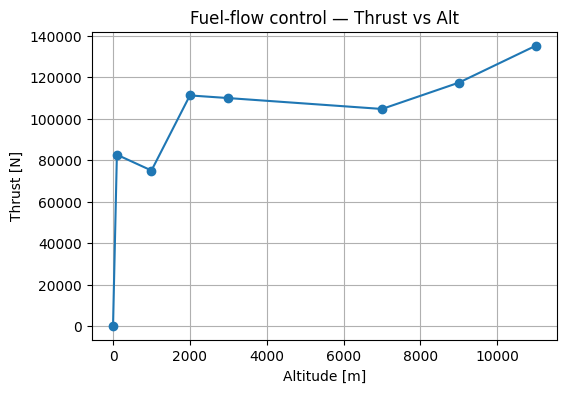

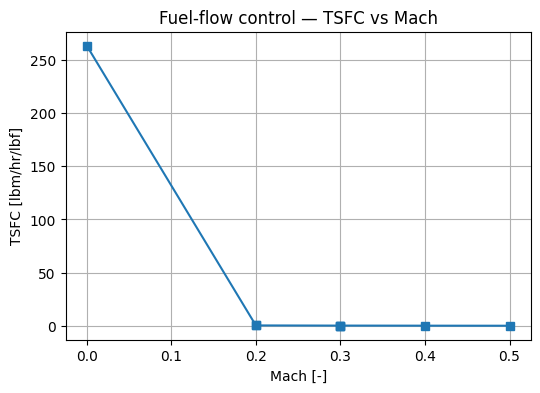

In [9]:
def plot_perf(perf_df, title):
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(perf_df['h_m'], perf_df['thrust_N'], marker='o')
    ax.set_xlabel('Altitude [m]')
    ax.set_ylabel('Thrust [N]')
    ax.set_title(title + ' — Thrust vs Alt')
    ax.grid(True)
    plt.show()

    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(perf_df['M'], perf_df['tsfc_lbm_hr_lbf'], marker='s')
    ax.set_xlabel('Mach [-]')
    ax.set_ylabel('TSFC [lbm/hr/lbf]')
    ax.set_title(title + ' — TSFC vs Mach')
    ax.grid(True)
    plt.show()

plot_perf(perf_mf, 'Fuel-flow control')

## “Fly” a time series (optional)
Define time-stamped commands with altitude/Mach/fuel and sample each step. This demonstrates how you could hook in a **pilot/auto-throttle** later.

In [10]:
def fly_timeseries(commands,
                   mdot_air=520.0,
                   dT_isa_C=0.0):
    rows = []
    t_accum = 0.0
    for cmd in commands:
        dt = float(cmd.get('dt', 1.0))
        wp = {'h_m': cmd['h_m'], 'M': cmd['M'], 'mf_fuel': cmd.get('mf_fuel', None), 'T_t4': cmd.get('T_t4', None)}
        perf, stn = fly_profile([wp], mdot_air=mdot_air, dT_isa_C=dT_isa_C)
        r = perf.iloc[0].to_dict()
        r['t_s'] = t_accum
        rows.append(r)
        t_accum += dt
    return pd.DataFrame(rows)

# Example “pilot script” (very small demo):
cmds = [
    {'dt': 5, 'h_m': 0,     'M': 0.20, 'mf_fuel': 1.4},
    {'dt': 5, 'h_m': 300,   'M': 0.20, 'mf_fuel': 1.4},
    {'dt': 5, 'h_m': 1500,  'M': 0.35, 'mf_fuel': 1.3},
    {'dt': 5, 'h_m': 6000,  'M': 0.65, 'mf_fuel': 1.1},
    {'dt': 5, 'h_m': 6000, 'M': 0.80, 'mf_fuel': 0.95},
]
timeline = fly_timeseries(cmds)
timeline

T_amb 288.15
p_amb 101325.0
2.nz     Nozzle
          T0 290.4552 [K]
          p0 104190.584 [Pa]
Fuel: 1400.0
fuel: 1400.0
thrust: 94908.86212297613
T_amb 286.2
p_amb 97772.53979656594
2.nz     Nozzle
          T0 288.4896 [K]
          p0 100537.656 [Pa]
Fuel: 1400.0
fuel: 1400.0
thrust: 94587.39039150605
T_amb 278.4
p_amb 84555.84112250838
2.nz     Nozzle
          T0 285.220799 [K]
          p0 92031.2845 [Pa]
Fuel: 1300.0
fuel: 1300.0
thrust: 151553.32756925127
T_amb 249.14999999999998
p_amb 47180.641625274184
2.nz     Nozzle
          T0 270.203175 [K]
          p0 62671.0960 [Pa]
Fuel: 1100.0
fuel: 1100.0
thrust: 225260.0483010626
T_amb 249.14999999999998
p_amb 47180.641625274184
2.nz     Nozzle
          T0 281.0412 [K]
          p0 71919.3397 [Pa]
Fuel: 950.0
fuel: 950.0
thrust: 239427.44984013733


,wp,h_m,M,thrust_N,fuel_kgps,sfc_kg_per_Ns,tsfc_lbm_hr_lbf,control,control_value,t_s
0,0,0.0,0.20,94908.862123,1.40,0.000015,0.520767,mf,1.40,0.0
1,0,300.0,0.20,94587.390392,1.40,0.000015,0.522537,mf,1.40,5.0
2,0,1500.0,0.35,151553.327569,1.30,0.000009,0.302831,mf,1.30,10.0
3,0,6000.0,0.65,225260.048301,1.10,0.000005,0.172398,mf,1.10,15.0
4,0,6000.0,0.80,239427.449840,0.95,0.000004,0.140079,mf,0.95,20.0


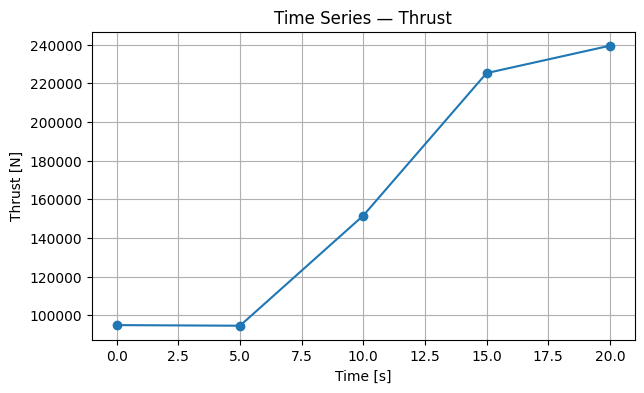

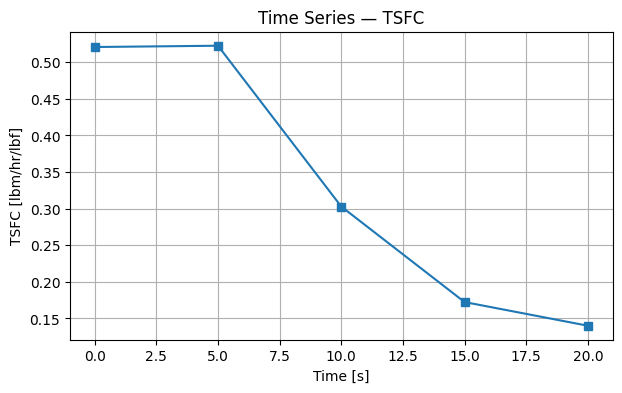

In [11]:
# Time-series plots
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(timeline['t_s'], timeline['thrust_N'], marker='o')
ax.set_xlabel('Time [s]'); ax.set_ylabel('Thrust [N]')
ax.set_title('Time Series — Thrust')
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(timeline['t_s'], timeline['tsfc_lbm_hr_lbf'], marker='s')
ax.set_xlabel('Time [s]'); ax.set_ylabel('TSFC [lbm/hr/lbf]')
ax.set_title('Time Series — TSFC')
ax.grid(True)
plt.show()